# Part 1: Load and Inspect Data

In [51]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult-modified.csv")

In [52]:
display(df.head())

,age,workclass,education,marital-status,race,sex,hours-per-week,income
0,39,Public,13,Single,White,Male,40,<=50K
1,50,Self-emp,13,Married,White,Male,13,<=50K
2,38,Private,9,Single,White,Male,40,<=50K
3,53,Private,7,Married,Black,Male,40,<=50K
4,28,Private,13,Married,Black,Female,40,<=50K


In [53]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.dtypes)

Rows: 10000, Columns: 8
age                 str
workclass           str
education         int64
marital-status      str
race                str
sex                 str
hours-per-week    int64
income              str
dtype: object


In [54]:
display(df.describe())
display(df.describe(include="object"))

,education,hours-per-week
count,10000.000000,10000.000000
mean,10.076600,40.530300
std,2.548172,12.277197
min,1.000000,1.000000
25%,9.000000,40.000000
50%,10.000000,40.000000
75%,12.000000,45.000000
max,16.000000,99.000000


/var/folders/cm/qlq4hthx30b13x6jzbvfq2wr0000gn/T/ipykernel_32830/4141271597.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,age,workclass,marital-status,race,sex,income
count,10000,10000,10000,10000,10000,10000
unique,72,4,2,5,2,2
top,31,Private,Single,White,Male,<=50K
freq,284,6947,5017,8556,6703,7621


Each row is an observation with data about a person's attributes including age, workclass, income, race, and marital-status. The target
attribute is the income. The income is represented either by an income greater than or less than 50k.

# Part 2: Identify Data Problems

In [55]:
df.isna().sum()

age               0
workclass         0
education         0
marital-status    0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64

In [56]:
print(df["age"].value_counts().head(10))
print(sorted(df["age"].unique(), key=str)) #Must convert to universal type first
print(df["workclass"].value_counts(dropna=False))

age
31    284
35    270
34    268
23    267
33    267
25    266
30    263
37    262
20    253
32    251
Name: count, dtype: int64
['17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '88', '90', '?']
workclass
Private     6947
Public      1317
Self-emp    1148
?            588
Name: count, dtype: int64


In [57]:
values = ["?", "", "NA", "nan", "unknown", "Unknown"]
for char in df.select_dtypes(exclude="number").columns:
    strip_values = df[char].astype(str).str.strip()
    found = {m: (strip_values == m).sum() for m in values if (strip_values ==m).sum() > 0}
    print(char, found)

age {'?': np.int64(198)}
workclass {'?': np.int64(588)}
marital-status {}
race {}
sex {}
income {}


In [58]:
num = len(df)
for char in ["age", "workclass"]:
    count = (df[char].astype(str).str.strip() == "?").sum()
    print(f"{char}: {count} records ({count / num *100:.2f}%)")

age: 198 records (1.98%)
workclass: 588 records (5.88%)


In [59]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  2601


# Part 3: Clean Data

In [60]:
df_clean = df.copy()
df_clean = df_clean.replace("?", np.nan)
print(df_clean.isna().sum())

age               198
workclass         588
education           0
marital-status      0
race                0
sex                 0
hours-per-week      0
income              0
dtype: int64


In [61]:
df_clean["age"] = pd.to_numeric(df_clean["age"])

In [62]:
age_med = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_med).astype(int)

In [63]:
df_clean["workclass"] = df_clean["workclass"].fillna("Unknown")

Duplicate-looking rows should not be deleted is because a lot of the categories of data are types of data that can truly be shared by multiple people. Identical rows are not proof of a true data-entry error.

In [64]:
print(df_clean.dtypes)
print(df_clean.isna().sum())

age               int64
workclass           str
education         int64
marital-status      str
race                str
sex                 str
hours-per-week    int64
income              str
dtype: object
age               0
workclass         0
education         0
marital-status    0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64


| Problem | Action taken | Reason for the decision |
|---|---|---|
| Missing age | Replaced ? with NaN, then filled the missing values with the median. | Only about 2% of ages were missing, and replacing them with the median barely changes the distribution. |
| Missing workclass | Replaced ? with NaN, then added an "Unknown" category. | There is too much variability to assign a random value, so these records were labeled as unknown instead. |
| Age data type | Converted age to a numeric type. | The ? placeholder caused age to be stored as text, so a numeric cast was needed to fix the formatting. |
| Duplicate-looking rows | Kept all rows. | Identical rows can be different people. |

# Part 4: Transform Data

In [65]:
min, max = df_clean["age"].min(), df_clean["age"].max()
df_clean["minmax"] = (df_clean["age"] - min) / (max - min)
print(df_clean["minmax"].min(),"\n",df_clean["minmax"].max())

0.0 
 1.0


In [66]:
hours = df_clean["hours-per-week"]
df_clean["hours_z"] = (hours - hours.mean()) / hours.std()
print(df_clean["hours_z"].mean(),"\n",df_clean["hours_z"].std())

2.4833468614815503e-16 
 1.0


In [67]:
df_clean["age_group"] = pd.cut(df_clean["age"],
                               bins = [16, 29, 44, 64, 90],
                               labels = ["Young Adult", "Adult", "Middle Age", "Senior"])
print(df_clean["age_group"].value_counts().sort_index())

age_group
Young Adult    2951
Adult          3959
Middle Age     2708
Senior          382
Name: count, dtype: int64


In [68]:
x = df_clean.drop(columns="income")
y = df_clean["income"]
x_encode = pd.get_dummies(x, columns=["workclass", "marital-status"])

In [69]:
print("Before encoding", x.shape)
print("After encoding", x_encode.shape)

Before encoding (10000, 10)
After encoding (10000, 14)


# Save CSV

In [70]:
x_encode["income"] = y
x_encode.to_csv("Lainson_Ben_adult_clean.csv", index=False)

# Part 5: Visualize Data

In [71]:
sns.set_theme(style = "whitegrid")

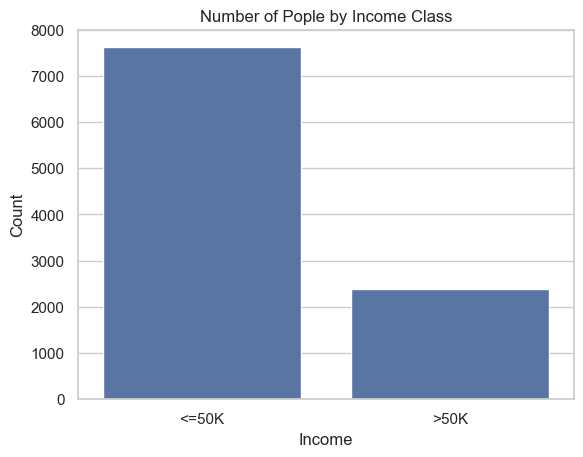

In [72]:
sns.countplot(data = df_clean, x = "income")
plt.title("Number of Pople by Income Class")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

The dataset is not balanced. There is a higher number of people in it earning less than or equal to 50K.

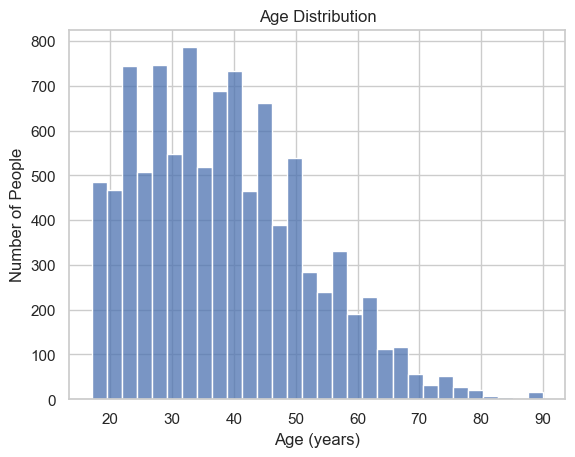

In [73]:
sns.histplot(data = df_clean, x = "age", bins = 30)
plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Number of People")
plt.show()

The dataset is right-skewed. There is a higher amount of younger people, mostly in 20s and 40s. 

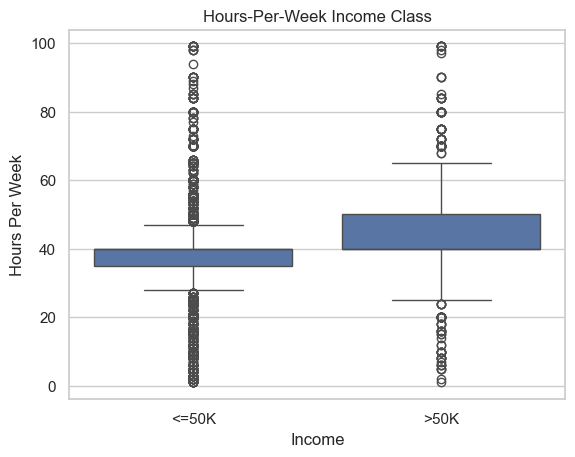

In [74]:
sns.boxplot(data = df_clean, x = "income", y = "hours-per-week")
plt.title("Hours-Per-Week Income Class")
plt.xlabel("Income")
plt.ylabel("Hours Per Week")
plt.show()

Both groups have a median of about 40 hours. Both groups have many outliers on both sides.

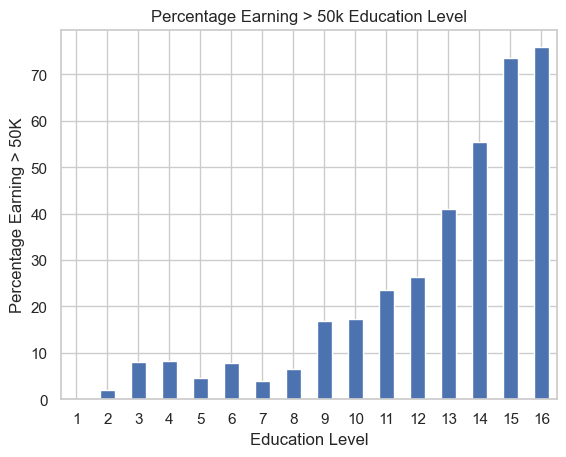

In [75]:
high_income = (df_clean["income"] == ">50K").groupby(df_clean["education"]).mean() * 100
high_income.plot(kind="bar")
plt.title("Percentage Earning > 50k Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage Earning > 50K")
plt.xticks(rotation=0)
plt.show()

The high-income percentage shows a exponential growth as the education level increases. The lowest levels have a very low income number while the highest are well above the 50k marker.

# Part 6: Response

23. The most important data-quality problem I found was the missing entries. ? was used as a placeholder in many situations which initially caused
    the data to show no missing values, which is wrong.
24. Choosing to replace the missing workclass was the best preprocessing decision I made that had a tremendous impact. Replacing it with unknown
    saved 588 rows from being filtered out.
25. I think the most important pattern reveal by my visualizations was the correlation between educatio-level and income. The graph showed a clear
    correlation between education-level and income. The higher the education level someone had, the higher income they made.
26. The dataset is not entirely ready... it still needs race, sex, and age_group to be reduced and cleaned like how we did in the examples above.